In [1]:
# Plot light curve and phase diagram

import matplotlib.pyplot as plt
import numpy as np
from astropy.timeseries import LombScargle
# from scipy import stats
# from scipy.stats import distributions
# import similaritymeasures

#Choose data path

path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250706'
object = 'V2400Oph'
channel = '1'
source = '6'

data = f'{path}{date}/export_txt'

In [2]:
#   Reading polarimetry data

data1 = np.loadtxt(f'{data}/{object}_ch{channel}_SRC{source}_polar.txt',skiprows=1)

t1=data1[:,0]
mag1=data1[:,2]
mag1_error=data1[:,3]

# Removendo a media dos dados

mag_mean1=np.mean(mag1)
mag_c1=mag1-mag_mean1
#mag_c1=mag1

In [3]:
#date = '20250701'
#object = 'V2400Oph'
#channel = '1'
#source = '6'
#data = f'{path}{date}/export_txt'

#data2 = np.loadtxt(f'{data}/{object}_ch{channel}_SRC{source}_polar.txt',skiprows=1)

#t2=data2[:,0]
#mag2=data2[:,2]
#mag2_error=data2[:,3]

# Removendo a media dos dados
#
#mag_mean2=np.mean(mag2)
#mag_c2=mag2-mag_mean2
#mag_c2=mag2

In [4]:
#time=np.concatenate((t1,t2,t3,t4))
#mag_c=np.concatenate((mag_c1,mag_c2,mag_c3,mag_c4))
#mag_error=np.concatenate((mag1_error,mag2_error,mag3_error,mag4_error))

time=1.*t1
mag_c=1.*mag_c1
mag_error=1.*mag1_error

In [5]:
#  Filter data
#
filter="no"
# filter="yes"

In [6]:
##### Lomb Scargle
#
# limites em minutos
p1=5.
p2=300.
# 
p1=p1/60./24.0
p2=p2/60./24.0
# 
# limites em dias
# p1=0.
# p2=1.
#
#
# Numero de frequencias
#
n_freq=int(1e6)
frequency = np.linspace(1./p2, 1./p1, n_freq)

In [7]:
#  Fazendo o Lomb-Scargle
#
#ls = LombScargle(time, mag_c)
ls = LombScargle(time, mag_c,mag_error)
power = ls.power(frequency)
probabilities = [0.001]
fap=ls.false_alarm_level(probabilities) 
#
best_frequency = frequency[np.argmax(power)]
best_period=1./best_frequency
print(' ')
print('Best period in days  ', best_period)
print('Best period in hours  ', best_period*24.)
print('Best period in minutes  ', best_period*24.*60.)
print('False alarm probability of 0.001  ',fap)
print(' ')

 
Best period in days   0.03366799216337644
Best period in hours   0.8080318119210346
Best period in minutes   48.48190871526207
False alarm probability of 0.001   [0.05427812]
 


In [8]:
# Calculando phase diagram
#
to=2460863.42808605
phase=((time-to)%best_period)/best_period

# Binning data in the best period
#
number_bins=10
center_bin=np.zeros(number_bins)
bin_means=np.zeros(number_bins)
bin_size=1./number_bins
bins = np.linspace(0, 1, number_bins+1)
digitized = np.digitize(phase, bins)
# print(bins)
# print(digitized)

In [9]:
for i in range(1, len(bins)):
    im=i-1
    center_bin[im]=bins[i]-0.5*bin_size
    bin_means[im]=np.mean(mag_c[digitized == i])
#    print(i,center_bin[im],bin_means[im]) 
#
#    Model sinuosoidal
# 
y_fit = ls.model(time, best_frequency)

In [10]:
# Filtrando
#
if (filter != "no"):
	f= open("bocet_fot_p1_509.txt","x")
	mag_filtered=np.zeros(len(mag_c))
	for i in range(0, len(mag_c)):
#
#    Aqui eu filtro por media do bin - nao eh bom
#
# 		mag_filtered[i]=mag[i]-bin_means[digitized[i]-1]
#  
#    Aqui filtro por Model sinuosoidal
# 
		mag_filtered[i]=mag_c[i]-y_fit[i]
		f.write(f"{time[i]} {mag_c[i]} {mag_filtered[i]} \n")
	
#
	f.close()

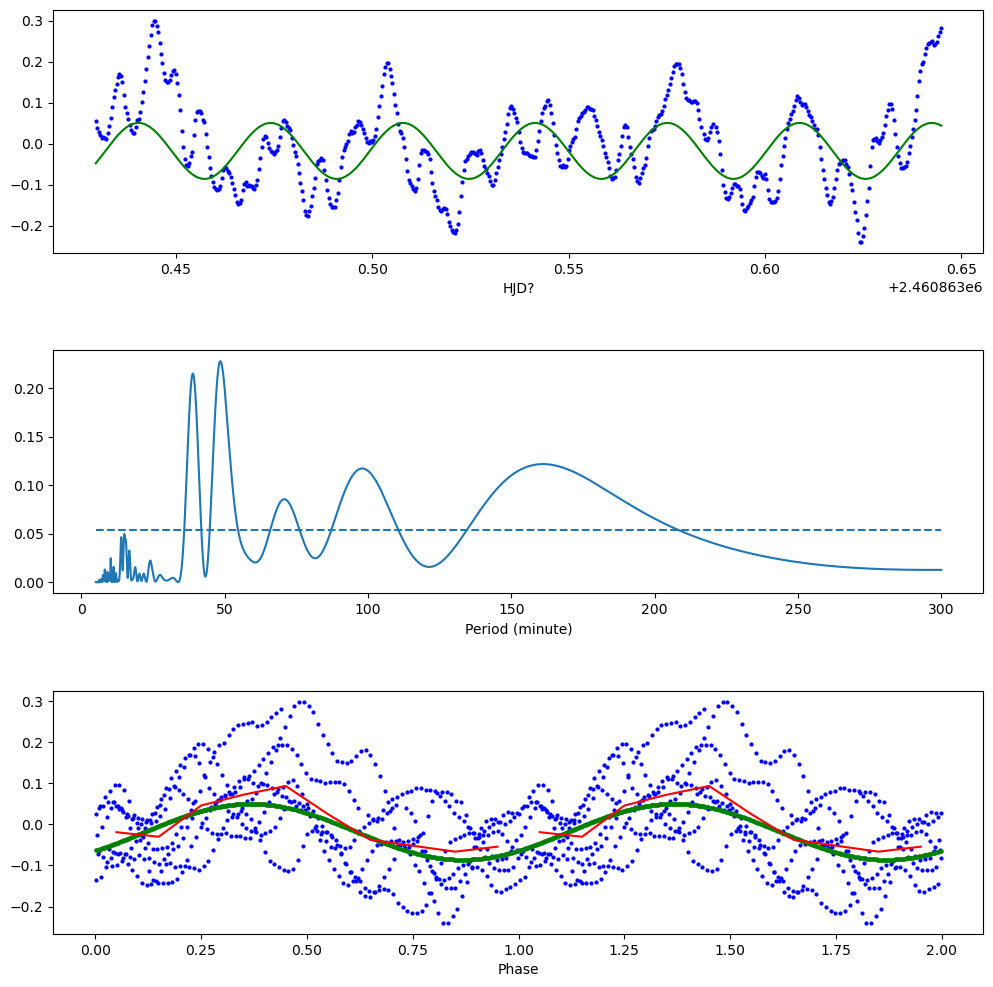

In [11]:
#### Plot

plt.close('all')

#f, ax = plt.subplots(2, sharex=True)
f, ax = plt.subplots(3, figsize=(12, 12), sharex=False)
f.subplots_adjust(hspace=0.4)
#f.align_ylabels(ax[0:1])

ax[0].plot(time,mag_c,'b.',markersize=4)
ax[0].plot(time,y_fit,'g-',markersize=4)
ax[0].set_xlabel('HJD?')
# ax[0].set_xlim(52455.2,52455.4)

ax[1].plot(1./frequency*24.*60.,power)
ax[1].set_xlabel('Period (minute)')
xmin=p1*24.*60.
xmax=p2*24.*60.
# ax[1].plot(1./frequency,power)
# ax[1].set_xlabel('Period (d)')
# xmin=p1
# xmax=p2
ax[1].hlines(fap,xmin,xmax,linestyles='dashed')

ax[2].plot(phase,mag_c,'b.',markersize=4)
ax[2].plot(phase+1.0,mag_c,'b.',markersize=4)
ax[2].plot(phase,y_fit,'g.',markersize=4)
ax[2].plot(phase+1.0,y_fit,'g.',markersize=4)
ax[2].plot(center_bin,bin_means,'r-',markersize=4)
ax[2].plot(center_bin+1.0,bin_means,'r-',markersize=4)
ax[2].set_xlabel('Phase')
# ax[2].set_xlim(0,2)
#ax[2].plot(t_fit,y_fit,'k-')

# print(time.size)
# print(time_b.size)
# print(time_v.size)
plt.show()